# Procurement Contract Awards Ingestion & Enrichment

## Project Overview

This notebook ingests and transforms NYC procurement contract award data to enrich the certified MWBE vendor intelligence dataset.

The objective of this workflow is to extend certification analytics into:
- procurement participation analytics
- vendor activity intelligence
- operational engagement analysis
- procurement enrichment workflows

The procurement dataset introduces transactional procurement activity that complements the static certification directory data.

# Procurement Data Source

The procurement dataset was sourced from:

## NYC Open Data — Recent Contract Awards

The dataset contains information related to:
- procurement award notices
- vendor participation
- agency procurement activity
- contract amounts
- procurement categories
- award timelines

This dataset was used to evaluate procurement engagement among certified MWBE firms.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import requests


In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
url = "https://data.cityofnewyork.us/resource/qyyg-4tf5.csv?$limit=50000"

contracts_df = pd.read_csv(url)

contracts_df.head()

C:\Users\kale2\AppData\Local\Temp\ipykernel_20180\396821169.py:3: DtypeWarning: Columns (0: contact_phone, 1: email, 2: additional_description_2, 3: printout_1, 4: document_links) have mixed types. Specify dtype option on import or set low_memory=False.
  contracts_df = pd.read_csv(url)


,request_id,start_date,end_date,agency_name,type_of_notice_description,category_description,short_title,selection_method_description,section_name,special_case_reason_description,...,printout_2,printout_3,document_links,event_date,building_name,street_address_1,street_address_2,city,state,zip_code
0,20260519016,2026-05-26T00:00:00.000,2026-05-26T00:00:00.000,Youth and Community Development,Award,Human Services/Client Services,Saturday Night Lights,Negotiated Acquisition,Procurement,Other (Describe below in Other Legally Mandate...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20260519017,2026-05-26T00:00:00.000,2026-05-26T00:00:00.000,Dept. of Social Svcs/Human Resources Administr...,Award,Human Services/Client Services,Home Care Services Program Citywide,Competitive Sealed Proposals/Pre-Qualified List,Procurement,Other (Describe below in Other Legally Mandate...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20260519026,2026-05-26T00:00:00.000,2026-05-26T00:00:00.000,Sanitation,Award,Goods,V-BELTS AND RELATED PRODUCTS,M/WBE Noncompetitive Small Purchase,Procurement,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20260519027,2026-05-26T00:00:00.000,2026-05-26T00:00:00.000,Finance,Award,Goods,Laptop Computers and Accessories,M/WBE Noncompetitive Small Purchase,Procurement,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20260519022,2026-05-26T00:00:00.000,2026-05-26T00:00:00.000,Dept. of Social Svcs/Human Resources Administr...,Award,Human Services/Client Services,Home Care Services Program Citywide,Competitive Sealed Proposals/Pre-Qualified List,Procurement,Other (Describe below in Other Legally Mandate...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
contracts_df.columns.tolist()

['request_id',
 'start_date',
 'end_date',
 'agency_name',
 'type_of_notice_description',
 'category_description',
 'short_title',
 'selection_method_description',
 'section_name',
 'special_case_reason_description',
 'pin',
 'due_date',
 'address_to_request',
 'contact_name',
 'contact_phone',
 'email',
 'contract_amount',
 'contact_fax',
 'additional_description_1',
 'additional_description_2',
 'additional_description_3',
 'other_info_1',
 'other_info_2',
 'other_info_3',
 'vendor_name',
 'vendor_address',
 'printout_1',
 'printout_2',
 'printout_3',
 'document_links',
 'event_date',
 'building_name',
 'street_address_1',
 'street_address_2',
 'city',
 'state',
 'zip_code']

# Entity Resolution & Vendor Matching

Vendor names were normalized using:
- uppercasing
- punctuation removal
- legal suffix removal


field served as the primary join key between:
- certification data
- procurement award data


In [5]:
contracts_clean = contracts_df.copy()

contracts_clean.columns = (
    contracts_clean.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

In [8]:
contracts_clean["vendor_name_clean"] = (
    contracts_clean["vendor_name"]
    .astype(str)
    .str.upper()
    .str.strip()
    .str.replace(",", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(" LLC", "", regex=False)
    .str.replace(" INC", "", regex=False)
    .str.replace(" CORP", "", regex=False)
    .str.replace(" CORPORATION", "", regex=False)
    .str.replace(" LTD", "", regex=False)
    .str.replace(" CO", "", regex=False)
)

In [6]:
date_cols = [
    "start_date",
    "end_date",
    "due_date",
    "event_date"
]

for col in date_cols:
    contracts_clean[col] = pd.to_datetime(
        contracts_clean[col],
        errors="coerce"
    )

## Contract Amount Cleaning

The contract_amount field contained formatting inconsistencies including:
- currency symbols
- commas
- mixed string formatting

The field was standardized and converted into numeric format to support:
- aggregation
- ranking
- procurement value analysis
- segmentation workflows


In [7]:
contracts_clean["contract_amount"] = (
    contracts_clean["contract_amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

contracts_clean["contract_amount"] = pd.to_numeric(
    contracts_clean["contract_amount"],
    errors="coerce"
)

In [9]:
contracts_clean["award_year"] = (
    contracts_clean["start_date"]
    .dt.year
)

In [ ]:


contracts_clean["contract_size_category"] = pd.cut(
    contracts_clean["contract_amount"],
    bins=[0, 100000, 1000000, 10000000, np.inf],
    labels=[
        "Small",
        "Medium",
        "Large",
        "Enterprise"
    ]
)

In [11]:
contracts_clean.to_csv(
    "../data/processed/nyc_recent_contract_awards_clean.csv",
    index=False
)

# Procurement Features

The following procurement intelligence features were engineered:

- procurement_contract_count
- total_procurement_value
- avg_procurement_value
- agency_count
- procurement_category_count
- years_since_last_award
- procurement_activity_score
- has_procurement_award

These features enabled:
- procurement participation analysis
- vendor engagement analysis
- operational activity scoring
- procurement opportunity gap analysis

In [12]:
vendor_procurement_features = (
    contracts_clean
    .groupby("vendor_name_clean")
    .agg(
        procurement_contract_count=("request_id", "count"),
        total_procurement_value=("contract_amount", "sum"),
        avg_procurement_value=("contract_amount", "mean"),
        max_procurement_value=("contract_amount", "max"),
        first_award_year=("award_year", "min"),
        most_recent_award_year=("award_year", "max"),
        agency_count=("agency_name", "nunique"),
        procurement_category_count=("category_description", "nunique")
    )
    .reset_index()
)

In [13]:
current_year = pd.Timestamp.today().year

vendor_procurement_features["years_since_last_award"] = (
    current_year - vendor_procurement_features["most_recent_award_year"]
)

vendor_procurement_features["procurement_activity_score"] = (
    vendor_procurement_features["procurement_contract_count"].rank(pct=True)
    + vendor_procurement_features["total_procurement_value"].rank(pct=True)
    + vendor_procurement_features["agency_count"].rank(pct=True)
) / 3

vendor_procurement_features["procurement_activity_score"] = (
    vendor_procurement_features["procurement_activity_score"]
    .round(2)
)

In [14]:
vendor_procurement_features.to_csv(
    "../data/processed/vendor_procurement_features.csv",
    index=False
)

# Procurement Enrichment Workflow

Vendor-level procurement features were aggregated and merged into the MWBE certification dataset using the standardized:
vendor_name_clean field.

In [ ]:
mwbe_df = pd.read_csv(
    "../data/processed/mwbe_vendor_intelligence.csv"
)

mwbe_enriched = mwbe_df.merge(
    vendor_procurement_features,
    on="vendor_name_clean",
    how="left"
)

In [16]:
mwbe_enriched["has_procurement_award"] = (
    mwbe_enriched["procurement_contract_count"]
    .notnull()
    .astype(int)
)

In [17]:
procurement_cols = [
    "procurement_contract_count",
    "total_procurement_value",
    "avg_procurement_value",
    "max_procurement_value",
    "agency_count",
    "procurement_category_count",
    "years_since_last_award",
    "procurement_activity_score"
]

mwbe_enriched[procurement_cols] = (
    mwbe_enriched[procurement_cols]
    .fillna(0)
)

In [18]:
mwbe_enriched.to_csv(
    "../data/processed/mwbe_vendor_intelligence_enriched.csv",
    index=False
)

# Procurement Participation Findings

The enrichment workflow identified that approximately: 7.75% of certified MWBE firms appeared in procurement award records.

This finding may reflect:
- procurement participation gaps
- limited procurement engagement
- dataset scope limitations
- vendor naming inconsistencies
- inactive certified firms

This result demonstrates the importance of:
- entity resolution
- procurement enrichment
- vendor matching workflows
- operational analytics pipelines


In [19]:
mwbe_enriched["has_procurement_award"].value_counts()

has_procurement_award
0    10620
1      892
Name: count, dtype: int64

In [20]:
(
    mwbe_enriched["has_procurement_award"]
    .mean()
    * 100
).round(2)

np.float64(7.75)

In [21]:
matched_firms = (
    mwbe_enriched["has_procurement_award"]
    .sum()
)

total_firms = len(mwbe_enriched)

match_pct = (
    matched_firms / total_firms * 100
).round(2)

print(f"""
Matched Firms: {matched_firms}
Total Firms: {total_firms}
Match Rate: {match_pct}%
""")


Matched Firms: 892
Total Firms: 11512
Match Rate: 7.75%



# Operational Intelligence Use Cases

The enriched procurement dataset supports analysis such as:

- Which industries demonstrate the highest procurement activity?
- Which boroughs contain the strongest procurement participation?
- Which firms exhibit high operational readiness but low procurement engagement?
- Which vendors appear operationally mature based on engineered capacity and activity metrics?
- Which vendors demonstrate broad agency diversification?

In [ ]:
industry_procurement = (
    mwbe_enriched
    .groupby("naics_sector")
    .agg(
        total_procurement_value=(
            "total_procurement_value",
            "sum"
        ),
        vendor_count=(
            "vendor_name_clean",
            "nunique"
        ),
        avg_procurement_value=(
            "total_procurement_value",
            "mean"
        )
    )
    .sort_values(
        "total_procurement_value",
        ascending=False
    )
)

industry_procurement.head(10)

In [ ]:
top_industries = (
    industry_procurement
    .head(10)
    .sort_values(
        "total_procurement_value",
        ascending=True
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_industries.index,
    top_industries["total_procurement_value"]
)

plt.title(
    "Top Industries by Procurement Value",
    fontsize=16,
    pad=15
)

plt.xlabel(
    "Total Procurement Value",
    fontsize=12
)

plt.ylabel(
    "NAICS Sector",
    fontsize=12
)

plt.tight_layout()

plt.show()

In [24]:
borough_summary = (
    mwbe_enriched["borough_clean"]
    .value_counts()
)

borough_summary

borough_clean
MANHATTAN    2117
BROOKLYN     1945
QUEENS       1829
BRONX         783
STATEN IS     306
Name: count, dtype: int64

In [25]:
borough_procurement = (
    mwbe_enriched
    .groupby("borough_clean")
    .agg(
        vendor_count=(
            "vendor_name_clean",
            "nunique"
        ),
        total_procurement_value=(
            "total_procurement_value",
            "sum"
        ),
        avg_capacity_score=(
            "vendor_capacity_score",
            "mean"
        )
    )
    .sort_values(
        "total_procurement_value",
        ascending=False
    )
)

borough_procurement

,vendor_count,total_procurement_value,avg_capacity_score
borough_clean,,,
MANHATTAN,2117,2.547489e+09,0.487411
QUEENS,1829,5.780021e+08,0.457370
BROOKLYN,1945,2.549056e+08,0.438576
STATEN IS,306,1.541890e+08,0.475490
BRONX,783,6.342312e+07,0.412912


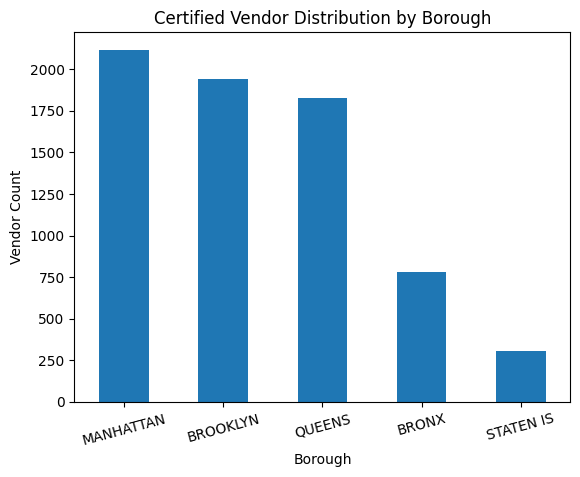

In [26]:
borough_summary.plot(
    kind="bar"
)

plt.title(
    "Certified Vendor Distribution by Borough"
)

plt.xlabel("Borough")
plt.ylabel("Vendor Count")

plt.xticks(rotation=15)

plt.show()

In [27]:
opportunity_vendors = mwbe_enriched[
    (
        mwbe_enriched[
            "operational_readiness_score"
        ] >= 0.7
    )
    &
    (
        mwbe_enriched[
            "procurement_activity_score"
        ] <= 0.3
    )
]

In [28]:
opportunity_vendors[
    [
        "vendor_formal_name",
        "naics_sector",
        "borough_clean",
        "operational_readiness_score",
        "procurement_activity_score",
        "vendor_capacity_score",
        "profile_completeness_pct"
    ]
].sort_values(
    "operational_readiness_score",
    ascending=False
).head(20)

,vendor_formal_name,naics_sector,borough_clean,operational_readiness_score,procurement_activity_score,vendor_capacity_score,profile_completeness_pct
8533,RAAD Construction Group,Construction,NaN,0.96,0.0,0.87,1.0
1976,Cardoza Plumbing Corp.,Construction,NaN,0.96,0.0,0.88,1.0
731,American Pile and Foundation LLC,Construction,NaN,0.96,0.0,0.89,1.0
826,Ansu Construction Inc.,Construction,NaN,0.96,0.0,0.87,1.0
7523,"Northeast Remsco Construction, Inc.",Construction,NaN,0.96,0.0,0.89,1.0
7810,Owen Steel Company Inc.,Manufacturing,NaN,0.96,0.0,0.89,1.0
10843,"Universal Construction Resources, Inc.",Construction,QUEENS,0.96,0.0,0.88,1.0
10804,"Unicorn Construction Enterprises, Inc.",Construction,NaN,0.96,0.0,0.87,1.0
7839,"Padilla Construction Services, Inc.",Construction,NaN,0.96,0.0,0.88,1.0
5197,"J.D'Annunzio & Sons, Inc.",Construction,NaN,0.96,0.0,0.88,1.0


# Data Engineering & Analytics Workflow

This notebook demonstrates several analytics engineering workflows, including:
- ingestion of external open data
- operational data cleaning
- entity resolution
- procurement enrichment
- feature engineering
- vendor-level aggregation
- operational intelligence analytics

---

# Technologies Used

- Python
- Pandas
- NumPy
- Jupyter Notebook
- NYC Open Data API
- DuckDB
- SQL

---

# Future Enhancements

Potential future enhancements include:
- fuzzy vendor matching
- geospatial procurement analysis
- procurement forecasting
- vendor clustering
- procurement recommendation systems
- advanced entity resolution pipelines
- dashboard integration with Streamlit

---

# Conclusion

This notebook demonstrates how procurement award data can be transformed into a vendor intelligence enrichment layer that complements MWBE certification analytics.

By combining:
- certification data
- procurement activity
- operational readiness features
- vendor capacity metrics
